<a href="https://colab.research.google.com/github/MINAL3009/histopathologic-cancer-classification/blob/main/notebooks%5CCustom_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Histopathologic Cancer Detection - CNN Pipeline
Run all cells step by step.

In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"srishtifarande","key":"4b7909e5fb918b8d86d94d521edf92d5"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
from pathlib import Path

DATA_DIR  = Path("/content/pcam_raw")
DATA_DIR.mkdir(exist_ok=True)

RAW_ZIP   = DATA_DIR / "histopathologic-cancer-detection.zip"
BASE_DIR  = DATA_DIR / "train"
FINAL_DIR = DATA_DIR / "final_dataset"

In [ ]:
!kaggle competitions download -c histopathologic-cancer-detection -p /content/pcam_raw

100% 6.31G/6.31G [07:06<00:00, 15.9MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile(RAW_ZIP, 'r') as z:
    z.extract('train_labels.csv', DATA_DIR)

print("Labels extracted")

Labels extracted


In [ ]:
import pandas as pd

df = pd.read_csv(DATA_DIR / "train_labels.csv")

df_0 = df[df.label == 0].sample(10000, random_state=42)
df_1 = df[df.label == 1].sample(10000, random_state=42)

df_subset  = pd.concat([df_0, df_1])
subset_ids = set(df_subset['id'].values)

print("Total selected:", len(subset_ids))

Total selected: 20000


In [ ]:
from tqdm import tqdm

BASE_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(RAW_ZIP, 'r') as z:
    all_files = [f for f in z.namelist()
                 if f.startswith("train/") and f.endswith(".tif")]

    for f in tqdm(all_files, desc="Extracting"):
        img_id = Path(f).stem
        if img_id in subset_ids:
            z.extract(f, DATA_DIR)

print(" Images extracted")

Extracting: 100%|██████████| 220025/220025 [00:17<00:00, 12721.70it/s]

 Images extracted


In [ ]:
import shutil

for cls in ["0", "1"]:
    (BASE_DIR / cls).mkdir(parents=True, exist_ok=True)

moved = 0
for _, row in df_subset.iterrows():
    img_id = row['id']
    label  = str(row['label'])

    src = DATA_DIR / "train" / f"{img_id}.tif"
    dst = BASE_DIR / label   / f"{img_id}.tif"

    if src.exists():
        shutil.move(str(src), str(dst))
        moved += 1

print(f" Moved {moved} images into class folders")

 Moved 0 images into class folders


In [ ]:
import random

for split in ["train", "val", "test"]:
    for cls in ["0", "1"]:
        (FINAL_DIR / split / cls).mkdir(parents=True, exist_ok=True)

random.seed(42)

for cls in ["0", "1"]:
    images = list((BASE_DIR / cls).glob("*.tif"))
    random.shuffle(images)

    n         = len(images)
    train_end = int(0.60 * n)
    val_end   = int(0.80 * n)

    for img in images[:train_end]:
        shutil.copy(str(img), str(FINAL_DIR / "train" / cls / img.name))

    for img in images[train_end:val_end]:
        shutil.copy(str(img), str(FINAL_DIR / "val"   / cls / img.name))

    for img in images[val_end:]:
        shutil.copy(str(img), str(FINAL_DIR / "test"  / cls / img.name))

print(" Split complete")

 Split complete


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (96, 96)
BATCH_SIZE = 32

# Train: augmentation + rescale
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    vertical_flip     = True
)

# Val / Test: ONLY rescale — no augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    FINAL_DIR / "train",
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary'
)

val_gen = val_test_datagen.flow_from_directory(
    FINAL_DIR / "val",
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False          # keeps .classes aligned with predictions
)

test_gen = val_test_datagen.flow_from_directory(
    FINAL_DIR / "test",
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)

print("Train :", train_gen.samples)
print("Val   :", val_gen.samples)
print("Test  :", test_gen.samples)

Found 12000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Train : 12000
Val   : 4000
Test  : 4000


In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(13, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'],     label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f"{title} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'],     label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f"{title} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_cnn_v1(input_shape=(94, 94, 3)):
    model = models.Sequential([

        # Block 1 – detect low-level edges/textures
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),

        # Block 2 – detect mid-level patterns
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.25),               # light dropout — baseline value
        layers.Dense(1,   activation='sigmoid')
    ])

    model.compile(
        optimizer = optimizers.Adam(1e-3),  # baseline learning rate
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model

model_v1 = build_cnn_v1()
model_v1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 92, 92, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,577 (15.20 MB)

 Trainable params: 3,984,577 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - accuracy: 0.6800 - loss: 0.6074 - val_accuracy: 0.7657 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.7646 - loss: 0.5053 - val_accuracy: 0.7567 - val_loss: 0.5179 - learning_rate: 0.0010
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7698 - loss: 0.4971
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.7786 - loss: 0.4897 - val_accuracy: 0.6727 - val_loss: 0.7285 - learning_rate: 0.0010
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - accuracy: 0.7968 - loss: 0.4489 - val_accuracy: 0.7790 - val_loss: 0.4791 - learning_rate: 5.0000e-04
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - accuracy: 0.7941 - loss: 0.4467 - val_accuracy: 0.7387 - val_loss: 0.5544 - learning_rate: 5.0000e-04
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 

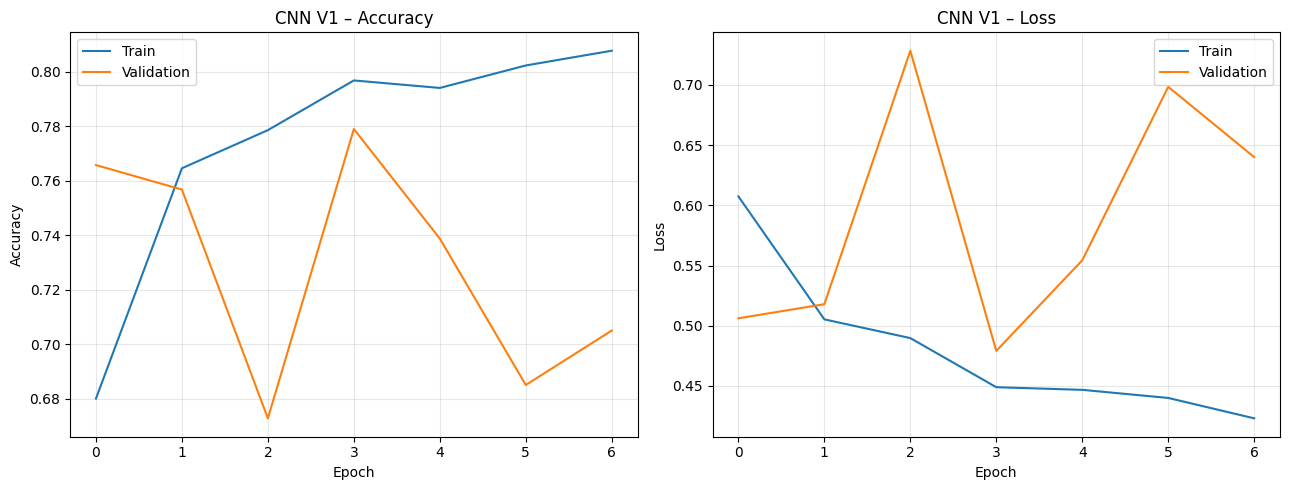

In [ ]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(patience=2, factor=0.5, monitor='val_loss', verbose=1)
]

history_v1 = model_v1.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 10,
    callbacks       = callbacks
)

plot_history(history_v1, "CNN V1")

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step
=== CNN V1 – Validation Set ===

              precision    recall  f1-score   support

  Normal (0)       0.72      0.90      0.80      2000
  Cancer (1)       0.87      0.66      0.75      2000

    accuracy                           0.78      4000
   macro avg       0.80      0.78      0.78      4000
weighted avg       0.80      0.78      0.78      4000



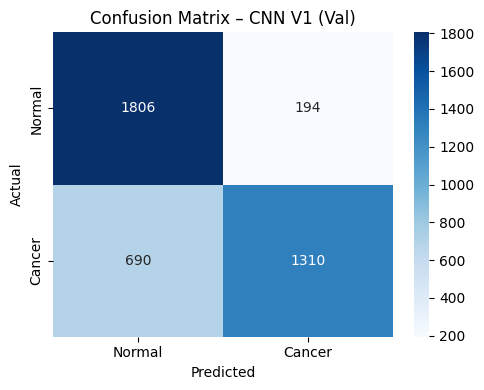

Final Training Accuracy   : 0.8077
Final Validation Accuracy : 0.7050


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_gen.reset()
preds_v1 = (model_v1.predict(val_gen) > 0.5).astype(int).flatten()

print("=== CNN V1 – Validation Set ===\n")
print(classification_report(val_gen.classes, preds_v1,
                             target_names=['Normal (0)', 'Cancer (1)']))

cm_v1 = confusion_matrix(val_gen.classes, preds_v1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Cancer'],
            yticklabels=['Normal','Cancer'])
plt.title("Confusion Matrix – CNN V1 (Val)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

final_train_acc_v1 = history_v1.history['accuracy'][-1]
final_val_acc_v1   = history_v1.history['val_accuracy'][-1]
print(f"Final Training Accuracy   : {final_train_acc_v1:.4f}")
print(f"Final Validation Accuracy : {final_val_acc_v1:.4f}")

In [ ]:
# ── CELL 15 : CNN V2 – Improved Architecture ────────────────
# Improvements over V1:
#    BatchNormalization after every Conv layer  → stable, faster training
#    Deeper blocks (2 conv layers per block)    → richer feature extraction
#    A third convolutional block (128 filters)  → captures high-level patterns
#    GlobalAveragePooling instead of Flatten    → reduces overfitting
#    Higher Dropout values (0.25→0.4, 0.5 head) → stronger regularisation
#    Lower learning rate (1e-3 → 1e-4)          → more stable convergence

def build_cnn_v2(input_shape=(96, 96, 3)):
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),           # increased from V1's 0 in conv blocks

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.35),           # stepped up further

        # Block 3 – new in V2
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.40),           # highest in conv path

        # Head – GlobalAvgPool replaces Flatten (less overfitting)
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.50),           # strong head regularisation
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer = optimizers.Adam(1e-4),   # lower LR → more stable
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model

model_v2 = build_cnn_v2()
model_v2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 323,105 (1.23 MB)

 Trainable params: 321,697 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 61s 124ms/step - accuracy: 0.7576 - loss: 0.5436 - val_accuracy: 0.5073 - val_loss: 1.5959 - learning_rate: 1.0000e-04
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - accuracy: 0.7778 - loss: 0.4968 - val_accuracy: 0.7130 - val_loss: 0.7017 - learning_rate: 1.0000e-04
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 130ms/step - accuracy: 0.7921 - loss: 0.4678 - val_accuracy: 0.8020 - val_loss: 0.4505 - learning_rate: 1.0000e-04
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.8033 - loss: 0.4412 - val_accuracy: 0.7818 - val_loss: 0.5369 - learning_rate: 1.0000e-04
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8051 - loss: 0.4396
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.8087 - loss: 0.4354 - val_accuracy: 0.7442 - val_loss: 0.5779 - learning_rate: 1.0000e-04
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 119ms/st

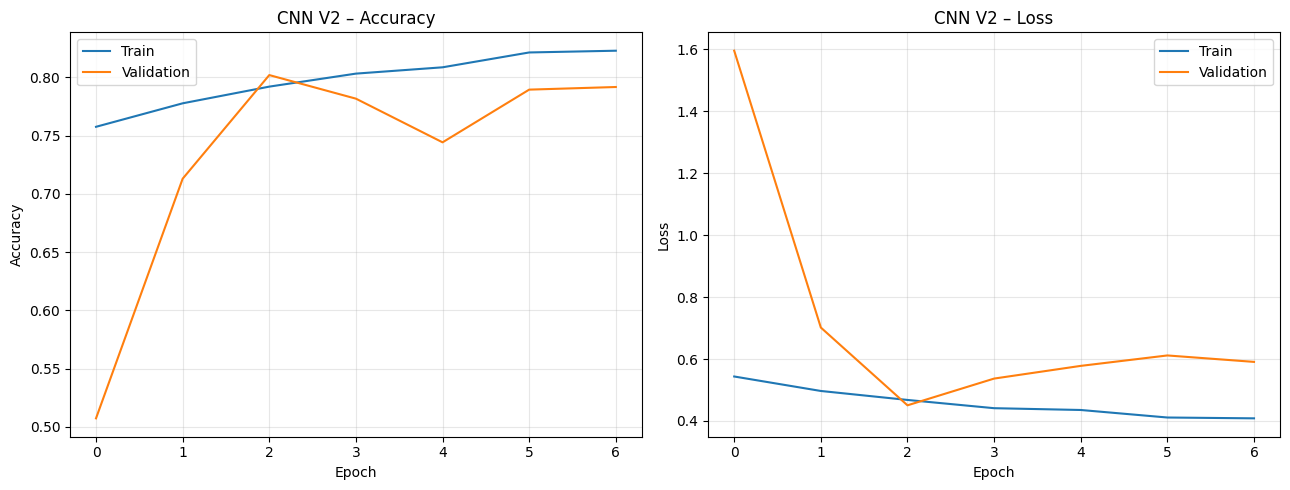

In [ ]:
# ── CELL 16 : Train CNN V2 ──────────────────────────────────
callbacks_v2 = [
    EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(patience=2, factor=0.5, monitor='val_loss', verbose=1)
]

history_v2 = model_v2.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 15,
    callbacks       = callbacks_v2
)

plot_history(history_v2, "CNN V2")

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step
=== CNN V2 – Validation Set ===

              precision    recall  f1-score   support

  Normal (0)       0.81      0.79      0.80      2000
  Cancer (1)       0.80      0.81      0.80      2000

    accuracy                           0.80      4000
   macro avg       0.80      0.80      0.80      4000
weighted avg       0.80      0.80      0.80      4000



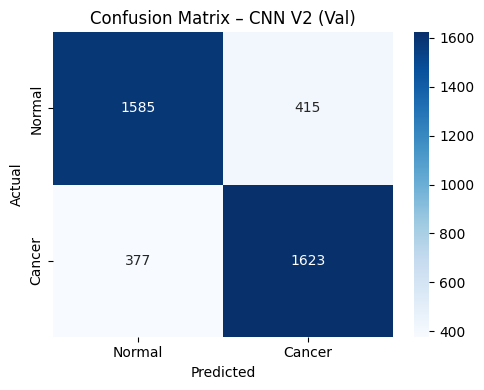

Final Training Accuracy   : 0.8229
Final Validation Accuracy : 0.7918


In [ ]:
# ── CELL 17 : Evaluate CNN V2 – Val Set ─────────────────────
val_gen.reset()
preds_v2 = (model_v2.predict(val_gen) > 0.5).astype(int).flatten()

print("=== CNN V2 – Validation Set ===\n")
print(classification_report(val_gen.classes, preds_v2,
                             target_names=['Normal (0)', 'Cancer (1)']))

cm_v2 = confusion_matrix(val_gen.classes, preds_v2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Cancer'],
            yticklabels=['Normal','Cancer'])
plt.title("Confusion Matrix – CNN V2 (Val)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

final_train_acc_v2 = history_v2.history['accuracy'][-1]
final_val_acc_v2   = history_v2.history['val_accuracy'][-1]
print(f"Final Training Accuracy   : {final_train_acc_v2:.4f}")
print(f"Final Validation Accuracy : {final_val_acc_v2:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step

  CNN V1  |  Test Acc: 0.7790  |  ROC-AUC: 0.8781
              precision    recall  f1-score   support

      Normal       0.72      0.91      0.80      2000
      Cancer       0.87      0.65      0.75      2000

    accuracy                           0.78      4000
   macro avg       0.80      0.78      0.78      4000
weighted avg       0.80      0.78      0.78      4000



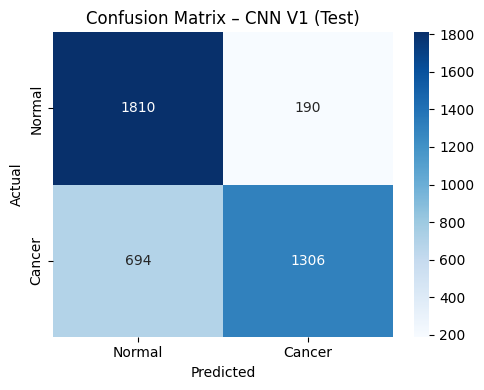

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step

  CNN V2  |  Test Acc: 0.8107  |  ROC-AUC: 0.8942
              precision    recall  f1-score   support

      Normal       0.82      0.80      0.81      2000
      Cancer       0.80      0.82      0.81      2000

    accuracy                           0.81      4000
   macro avg       0.81      0.81      0.81      4000
weighted avg       0.81      0.81      0.81      4000



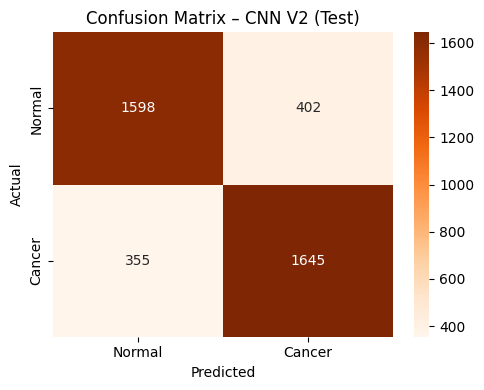

In [ ]:
# ── CELL 18 : Test Set Evaluation – Both Models ─────────────
from sklearn.metrics import roc_auc_score

def evaluate_test(model, generator, name, cmap='Oranges'):
    generator.reset()
    probs  = model.predict(generator).flatten()
    preds  = (probs > 0.5).astype(int)
    labels = generator.classes

    acc = (preds == labels).mean()
    auc = roc_auc_score(labels, probs)

    print(f"\n{'='*50}")
    print(f"  {name}  |  Test Acc: {acc:.4f}  |  ROC-AUC: {auc:.4f}")
    print(f"{'='*50}")
    print(classification_report(labels, preds,
                                 target_names=['Normal','Cancer']))

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Normal','Cancer'],
                yticklabels=['Normal','Cancer'])
    plt.title(f"Confusion Matrix – {name} (Test)")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    return acc, auc

acc1, auc1 = evaluate_test(model_v1, test_gen, "CNN V1", cmap='Blues')
acc2, auc2 = evaluate_test(model_v2, test_gen, "CNN V2", cmap='Oranges')



  Model              Val Acc   Test Acc    ROC-AUC
  CNN V1              0.7050     0.7790     0.8781
  CNN V2              0.7918     0.8107     0.8942

  📈 CNN V2 improved test accuracy by +3.17% over CNN V1


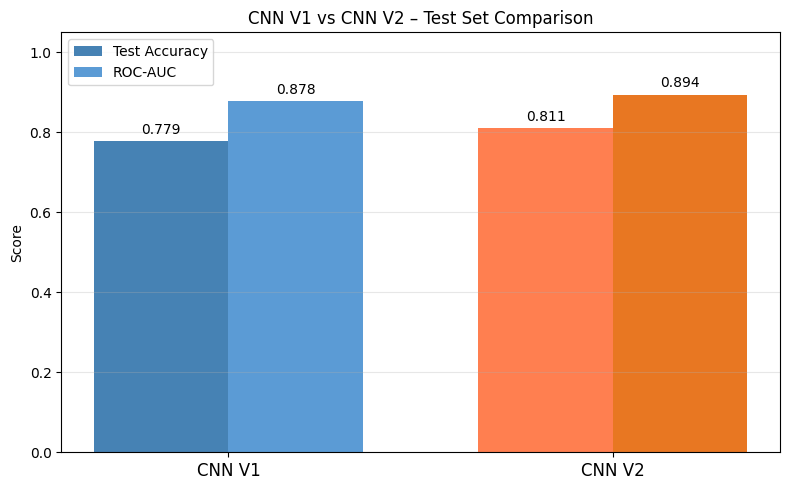

In [ ]:

# ── CELL 19 : Side-by-Side Comparison ──────────────────────
print("\n" + "="*55)
print(f"  {'Model':<15} {'Val Acc':>10} {'Test Acc':>10} {'ROC-AUC':>10}")
print("="*55)
print(f"  {'CNN V1':<15} {final_val_acc_v1:>10.4f} {acc1:>10.4f} {auc1:>10.4f}")
print(f"  {'CNN V2':<15} {final_val_acc_v2:>10.4f} {acc2:>10.4f} {auc2:>10.4f}")
print("="*55)

improvement = (acc2 - acc1) * 100
print(f"\n  📈 CNN V2 improved test accuracy by {improvement:+.2f}% over CNN V1")

# Bar chart
names  = ["CNN V1", "CNN V2"]
accs   = [acc1,  acc2]
aucs   = [auc1,  auc2]
colors = ['steelblue', 'coral']

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Test Accuracy', color=colors)
bars2 = ax.bar(x + width/2, aucs, width, label='ROC-AUC',
               color=['#5b9bd5','#e87722'])

ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('CNN V1 vs CNN V2 – Test Set Comparison')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=12)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()